# Data Exploration
This notebook is for exploring the relationships between customer churn and other columns in the dataset

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Loading the Dataset

In [2]:
df = pd.read_csv("../data/clean/dataset.csv")

In [8]:
df.head(1)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0


In [9]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='str')

## Visualizing Churn

([<matplotlib.axis.XTick at 0x7f23ab3b2900>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

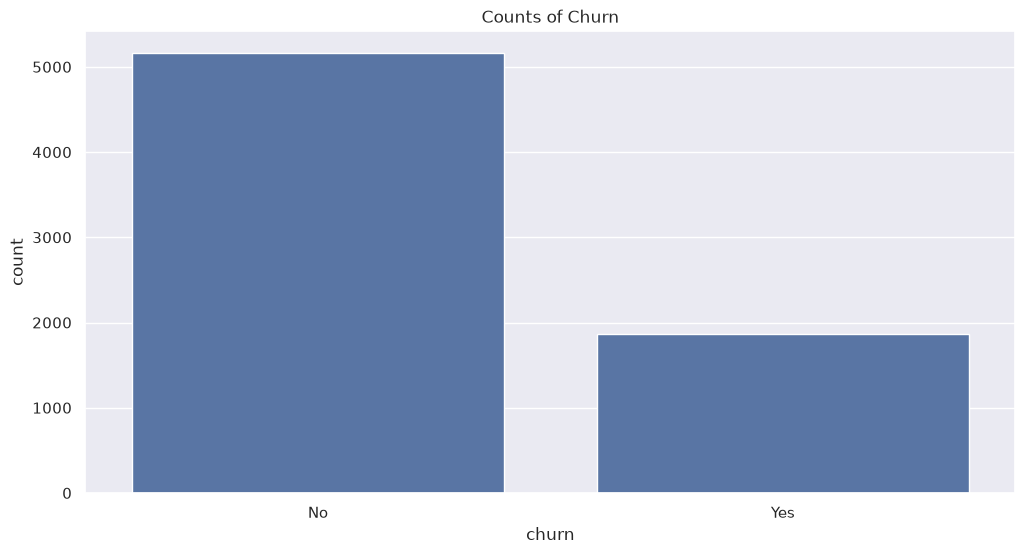

In [7]:
fig, ax = plt.subplots(figsize=(12,6))

sns.countplot(data=df, x="churn")

plt.title("Counts of Churn")

plt.xticks([0, 1], ["No", "Yes"])

There's a large class imbalance that needs to be accounted for in the modeling phase 

## Numerical Distributions

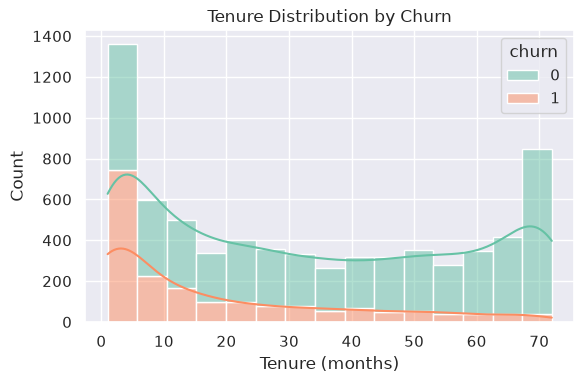

In [7]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="churn", kde=True,
             multiple="stack", palette="Set2")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.tight_layout()
plt.show()

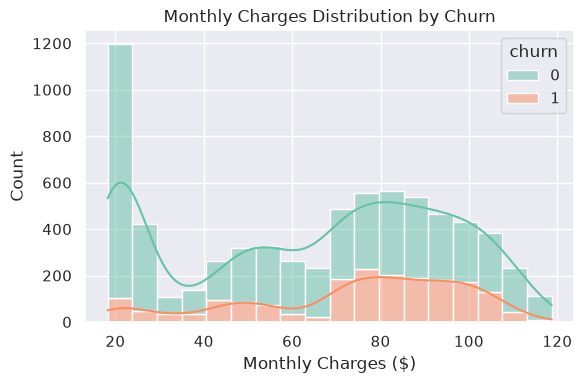

In [8]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="monthly_charges", hue="churn", kde=True,
             multiple="stack", palette="Set2")
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

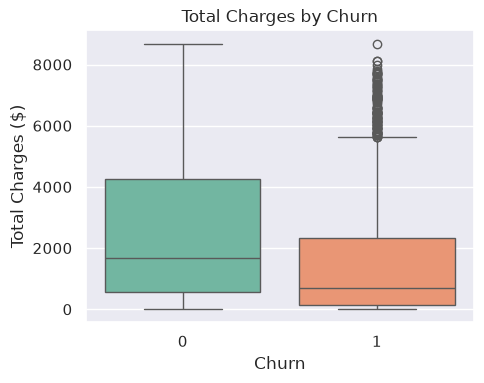

In [10]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x="churn", y="total_charges",
            hue="churn", palette="Set2", legend=False)
plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")
plt.tight_layout()
plt.show()

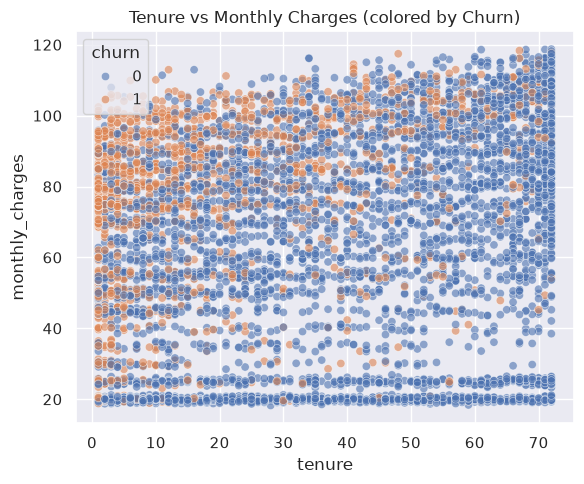

In [11]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="tenure", y="monthly_charges",
                 hue="churn", alpha=0.6)
plt.title("Tenure vs Monthly Charges (colored by Churn)")
plt.tight_layout()
plt.show()

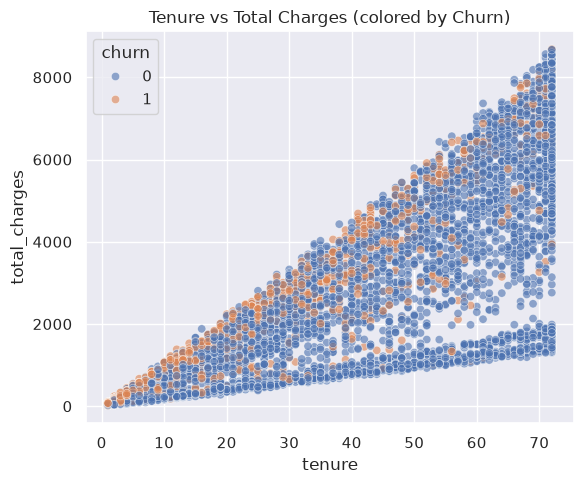

In [14]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="tenure", y="total_charges",
                 hue="churn", alpha=0.6)
plt.title("Tenure vs Total Charges (colored by Churn)")
plt.tight_layout()
plt.show()

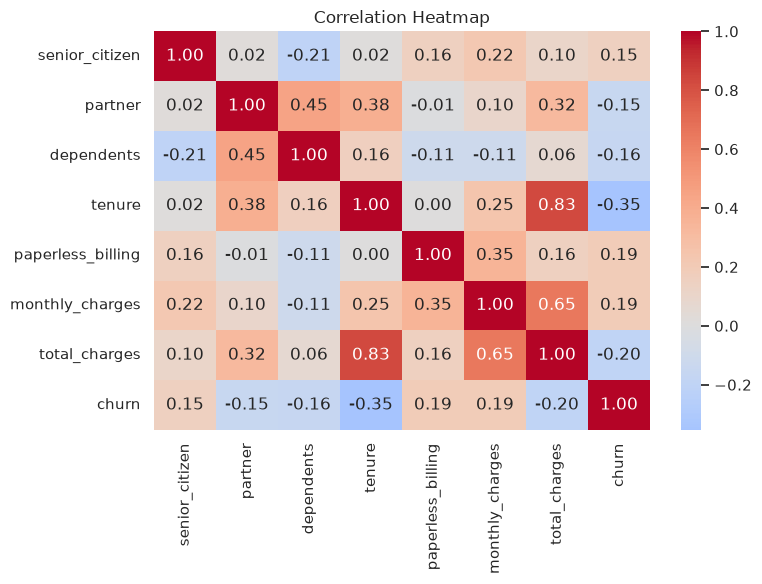

In [15]:
numeric_cols = ["senior_citizen", "partner", "dependents", "tenure",
                 "paperless_billing", "monthly_charges", "total_charges",
                 "churn"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Categorical Variables

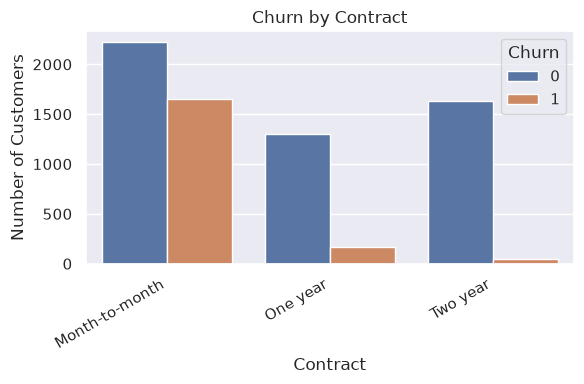

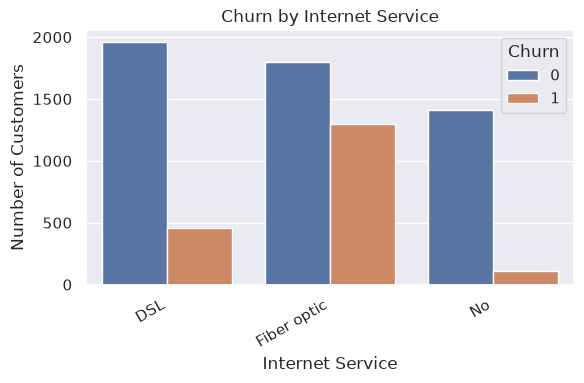

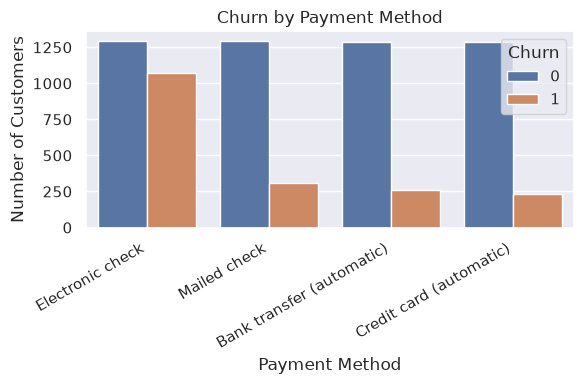

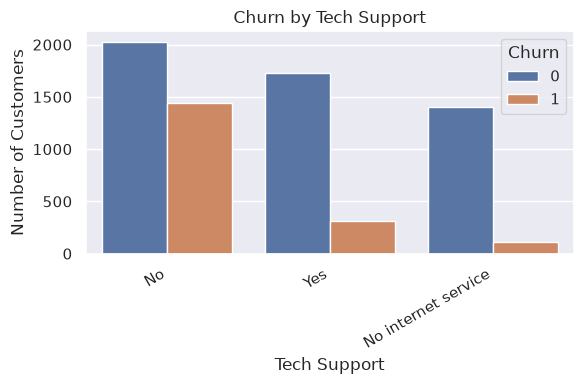

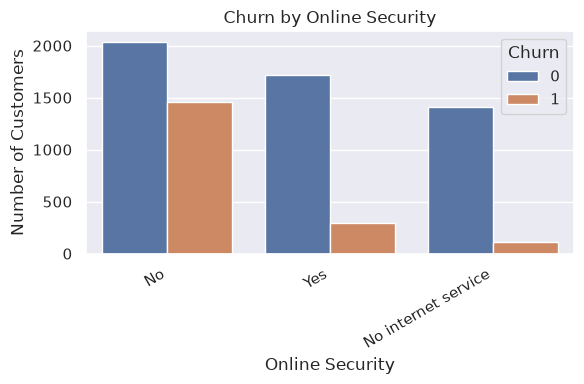

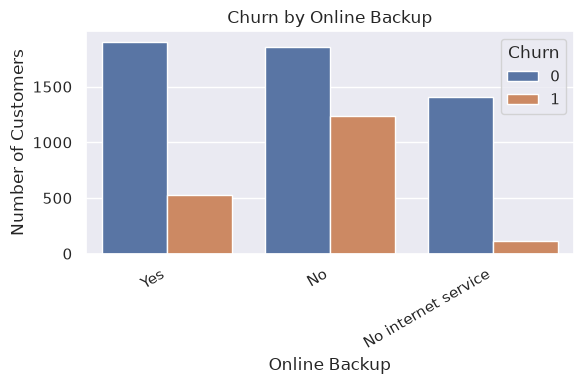

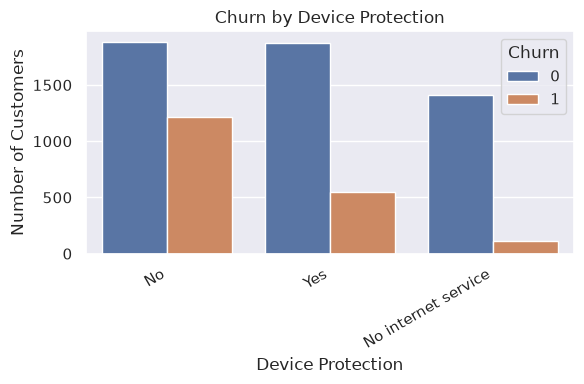

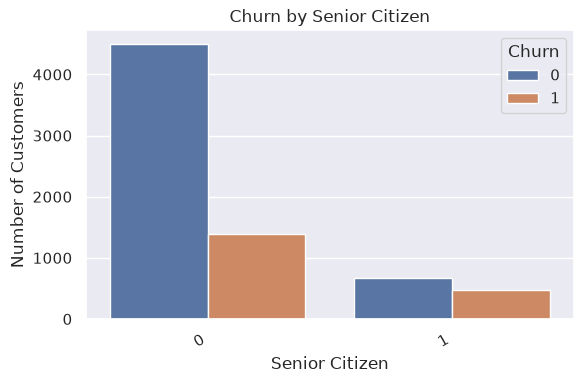

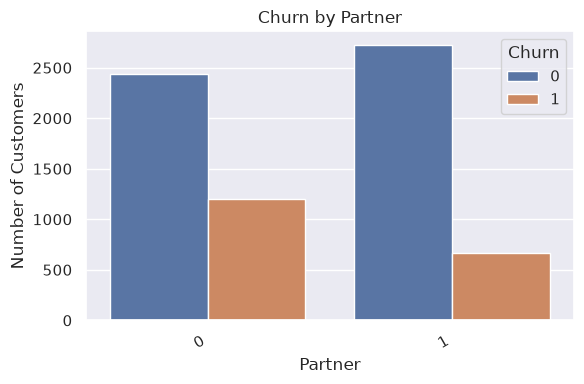

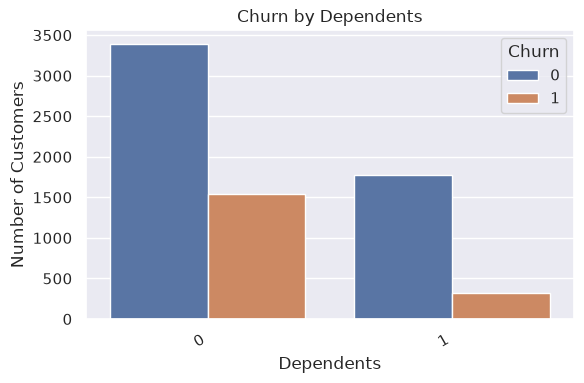

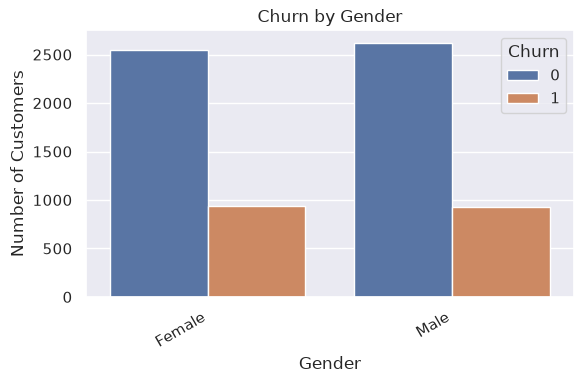

In [5]:
categorical_cols = [
    "contract", "internet_service", "payment_method", "tech_support",
    "online_security", "online_backup", "device_protection",
    "senior_citizen", "partner", "dependents", "gender",
]
 
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="churn",)
    plt.title(f"Churn by {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()


## 

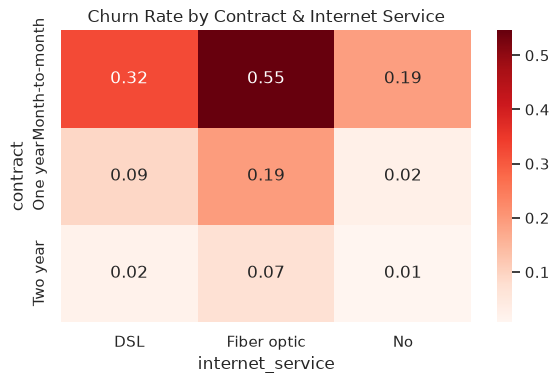

In [16]:
pivot = df.pivot_table(values="churn", index="contract",
                        columns="internet_service", aggfunc="mean")
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Churn Rate by Contract & Internet Service")
plt.tight_layout()
plt.show()

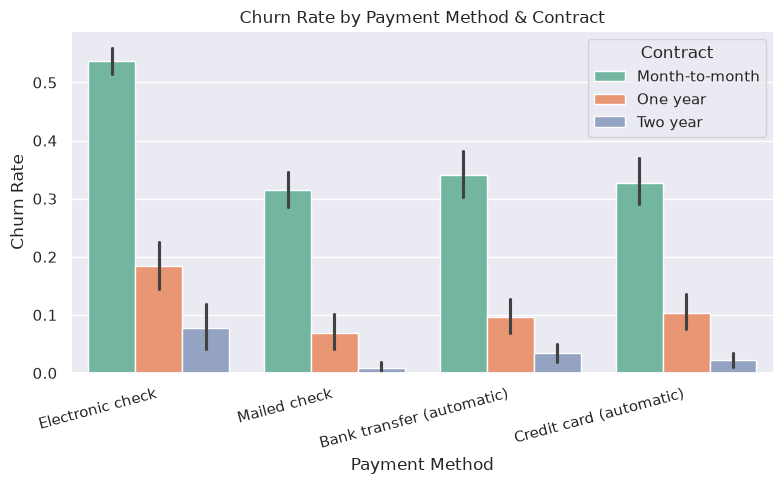

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="payment_method", y="churn", hue="contract",
            palette="Set2")
plt.title("Churn Rate by Payment Method & Contract")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Contract")
plt.tight_layout()
plt.show()

## Key Takeaways — Telco Churn

- Contract type is the strongest predictor
- Tenure matters most
- Fiber optic churns more than DSL
- Electronic check payers churn most
- Missing support/security add-ons ~doubles churn
- Seniors, singles, and no-dependents churn more gender has no effect.